This notebook develops a machine learning model to predict customer churn risk using behavioural purchasing features derived from RFM analysis. Predicting churn enables proactive retention strategies and improved customer lifetime value.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
rfm = pd.read_csv('rfm_dataset.csv')
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,New
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,New
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,Standard
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,Standard
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,Standard


In [5]:
rfm['Churn'] = np.where(rfm['Recency'] > 90, 1, 0)

In [6]:
x= rfm[['Recency', 'Frequency', 'Monetary']]
y= rfm['Churn']

In [8]:
x_train, x_test, y_train, y_test= train_test_split(
    x,y,
    test_size= 0.2,
    random_state=42
)

In [9]:
scaler= StandardScaler()
x_train= scaler.fit_transform(x_train)
x_test= scaler.transform(x_test)

In [10]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = model.predict(x_test)

In [12]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3708
           1       1.00      1.00      1.00     14710

    accuracy                           1.00     18418
   macro avg       1.00      1.00      1.00     18418
weighted avg       1.00      1.00      1.00     18418



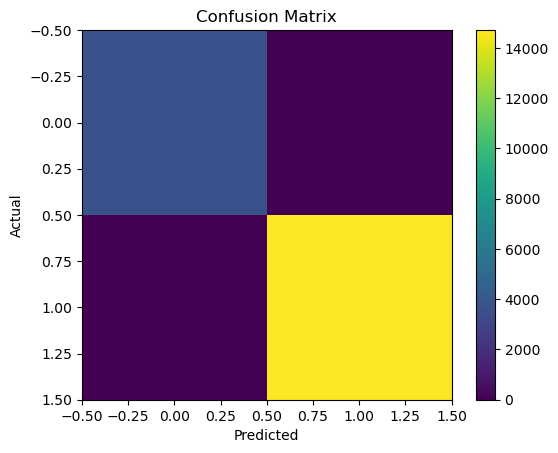

In [13]:
cm= confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [15]:
Importance = pd.DataFrame({
    'Feature':['Recency', 'Frequency', 'Monetary'],
    'Importance': model.feature_importances_
}).sort_values (by= 'Importance', ascending = False)

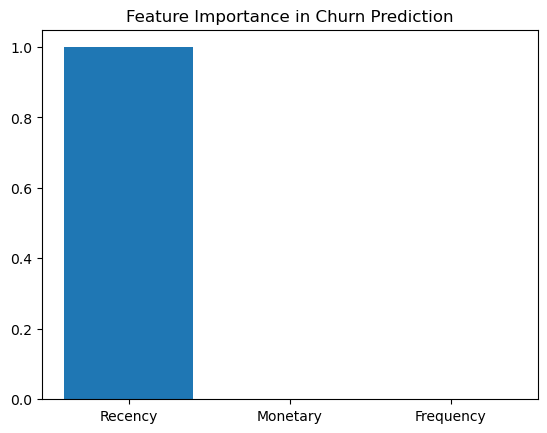

In [17]:
plt.figure()
plt.bar(Importance['Feature'], Importance['Importance'])
plt.title('Feature Importance in Churn Prediction')
plt.show()

The churn prediction model identifies customer recency as the strongest predictor of churn risk, indicating that inactivity duration is a critical behavioural signal. Customers with declining purchase frequency and lower monetary value also demonstrate elevated churn probability. These findngs support targeted retention strategies focused on recently inactive customers.